# Michael Vazquez<br>Econ 570, Midterm<br>Forecasting Interest Rates and the Impact on Industrial Production<br>Link to code: https://github.com/Vazquez-Michael-V/570_homework/blob/main/midterm/econ_570_midterm.ipynb


# <center><u><b>Forecasting Dataset and Timeframes</b></u></center>
&nbsp;&nbsp;&nbsp;&nbsp;The provided dataset is 10 year U.S. Treasury Bond interest rates at business end of week, ie Friday, frequency sampled from January 2000 to December 2025. Forecasts will be made of the 10 year U.S. Treasury Bond interest rate using five models. For all models, the training timeframe is from January 2000 to December 2010, and the holdout timeframe is from January 2011 to December 2025. More concisely:


**Full timeframe of the dataset:**
2000-01-07 - 2025-12-26, T = 1,356 end of business week observations.

**Training timeframe:**
2000-01-07 - 2010-12-31, R = 574 end of business week observations.

**Holdout timeframe:**
2011-01-07 - 2025-12-26, P = 782 forecasts to be made.

**Note 1:** End of business week in the context of this analysis is Friday. No information was provided concerning observations on which a given Friday is a holiday.

**Note 2:** The values of T, R, and P are further explained in Question 1.1.


<h1><center><u><b>Models</b></u></center></h1>
&nbsp;&nbsp;&nbsp;&nbsp;We are given five naive forecasting models to analyze the 10 year U.S. Treasury Bond interest rate at a forecast horizon of h = 1 week ahead.

**General Form of Simple Mean Models:**
$$\hat{y}_{t+1|t} = \frac{1}{S}\sum_{i=t-S+1}^{t} y_i$$

**Model 1A, Simple Mean with $S=1$:**
$$\hat{y}_{t+1|t} = y_t$$

**Model 1B, Simple Mean with $S=4$:**
$$\hat{y}_{t+1|t} = \frac{1}{4}\sum_{i=t-3}^{t} y_i$$

**Model 1C, Simple Mean with $S=52$:**
$$\hat{y}_{t+1|t} = \frac{1}{52}\sum_{i=t-51}^{t} y_i$$

**Random Walk Models**<br>Here we take the mathematical expectation to obtain the model estimates.<br>

**Model 2, Random Walk with Drift (RWD):**
$$y_t = \alpha + y_{t-1} + \varepsilon_t \implies \hat{y}_{t+1|t} = y_t + \hat{\alpha}_t, \quad \hat{\alpha}_t = \frac{y_t - y_1}{t-1}$$

**Model 3, Random Walk (RW):**
$$y_t = y_{t-1} + \varepsilon_t \implies \hat{y}_{t+1|t} = y_t$$



# Imports.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import warnings
# Suppress ARIMA convergence warnings, as we will only use ARIMA for
# validating the random walk models. 
warnings.filterwarnings('ignore', category=ConvergenceWarning)

import seaborn as sns

import sympy as sp

import os

from IPython.display import display, Math, Image


plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    # This font neatly displays Greek letters in plots.
    'mathtext.fontset': 'cm',
    'axes.grid': True,
    'grid.alpha': 0.35
    # 'axes.spines.top': False,
    # 'axes.spines.right': False
})



# Module that I made for summary statistics of interest to Econ 570.
# More functions may be added later in the course.
from econ_570_mod.summary_statistics import summary_statistics



# Notebook variables.

In [3]:
# These dates will be used throughout the notebook.
TRAIN_START = '2000-01-07'
TRAIN_END = '2010-12-31'
HOLD_START = '2011-01-07'
HOLD_END = '2025-12-26'

# Setup model labels and colors to keep consistent color theme throughout
# the notebook.
MODEL_LABELS = ['Model 1A (S=1)', 'Model 1B (S=4)', 'Model 1C (S=52)', 'Model 2 (RWD)', 'Model 3 (RW)']
MODEL_COLORS = ['#1f77b4', 'gold', '#2ca02c', '#d62728', '#9467bd']
# Forecast.
FC_COLS = ['fc_1a', 'fc_1b', 'fc_1c', 'fc_2', 'fc_3']
# Errors.
ERR_COLS = ['e_1a',  'e_1b',  'e_1c',  'e_2',  'e_3']




# Read and clean the 10 year U.S. Treasury Bond Interest Rate data.

In [4]:
# ir for interest rate.
df_ir = pd.read_excel(
    r'Midterm 10-Year Bond Rate - Interest Rate Data.xlsx',
    sheet_name='Weekly, Ending Friday'
).rename(
    columns={
        'observation_date': 'date',
        'WGS10YR': 'rate'
    },
    errors='raise'
).astype(
    {
        'date': 'datetime64[ns]',
        'rate': 'float64'
    }
).sort_values(
    by=['date']
).reset_index(drop=True)

# As discussed in the both the notebook intro and the README tab of the excel
# file, all dates should be Fridays.
assert df_ir['date'].dt.day_name().drop_duplicates().to_list() == ['Friday'],\
    "At least one date in the dataset is not a Friday."

# Nulls in the 'date' or 'rate' column would causes forecasting issues.
for col in df_ir:
    assert not df_ir[col].hasnans, f"Column '{col}' has at least one nan value."

# Ensure df_ir is the full timeframe specified in the midterm.
df_ir = df_ir.loc[(df_ir['date'].between(TRAIN_START, HOLD_END, inclusive='both')), :].reset_index(drop=True)

# Check that the data is actually weekly. In other words, check that there is a time 
# difference of 7 days between each observation. Note that df_ir has
# already been ordered by date ASC.
ser_week_check = df_ir.loc[:, 'date']\
    .copy()\
    .diff()\
    .dt.days\
    .dropna()

assert ser_week_check.loc[ser_week_check != 7].empty,\
    "Differencing observations, found a difference not equal to 7."

print("df_ir['date'] describe:")
display(df_ir['date'].describe())
# Set date as index to ensure reliable .shift() and .rolling() on time series.
df_ir = df_ir.set_index('date')

ser_num_fridays = df_ir.index.year.to_series().value_counts(dropna=False).sort_index()
print("Years with more than 52 Fridays:")
display(ser_num_fridays.loc[ser_num_fridays > 52])
# There are 52 weeks in a year, but depending on year start day and leap year there can
# be 53 Fridays in a year.
assert ser_num_fridays.loc[ser_num_fridays > 53].empty,\
    "There is at least one year with more than 53 Fridays."

print("df_ir info:")
print(df_ir.info(show_counts=True, verbose=True))
print(f"df_ir shape: {df_ir.shape}")
print("df_ir sample:")
display(df_ir.sample(n=10))


df_ir['date'] describe:


count                   1356
mean     2012-12-31 12:00:00
min      2000-01-07 00:00:00
25%      2006-07-05 06:00:00
50%      2012-12-31 12:00:00
75%      2019-06-29 18:00:00
max      2025-12-26 00:00:00
Name: date, dtype: object

Years with more than 52 Fridays:


date
2004    53
2010    53
2016    53
2021    53
Name: count, dtype: int64

df_ir info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1356 entries, 2000-01-07 to 2025-12-26
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rate    1356 non-null   float64
dtypes: float64(1)
memory usage: 21.2 KB
None
df_ir shape: (1356, 1)
df_ir sample:


,rate
date,
2012-04-13,2.04
2010-11-26,2.84
2004-05-21,4.74
2025-12-05,4.10
2016-01-15,2.10
2020-03-06,0.96
2015-11-13,2.32
2020-02-28,1.29
2021-04-23,1.58


# Question 1.1 - Values of T, R, and P.

In [5]:
# The data has already been cleaned, so the values of T, R, and P here are accurate.
T = df_ir.shape[0]
R = df_ir.loc[TRAIN_START:TRAIN_END, :].shape[0]
P = df_ir.loc[HOLD_START:HOLD_END, :].shape[0]

assert T == R + P, f"The sum of R and P should be {T} but is {R + P}."

print(f"T = {T}, the total number of observations over the entire timeframe of the sample interest rate data.")
print(f"R = {R}, the number of observations over the training timeframe.")
print(f"P = {P}, the number of forecasts to be made over the holdout timeframe.")

# Place T, R, and P info into a DataFrame for an easy tabular display.
df_trp = pd.DataFrame(data={
    'variable': ['T', 'R', 'P'],
    'value': [T, R, P],
    'start_date': [
        df_ir.index.min().strftime('%Y-%m-%d'),
        TRAIN_START,
        HOLD_START
    ],
    'end_date': [
        df_ir.index.max().strftime('%Y-%m-%d'),
        TRAIN_END,
        HOLD_END
    ]
})
display(df_trp)

T = 1356, the total number of observations over the entire timeframe of the sample interest rate data.
R = 574, the number of observations over the training timeframe.
P = 782, the number of forecasts to be made over the holdout timeframe.


,variable,value,start_date,end_date
0,T,1356,2000-01-07,2025-12-26
1,R,574,2000-01-07,2010-12-31
2,P,782,2011-01-07,2025-12-26


#### Discussion on the values of T, R, and P.
&nbsp;&nbsp;&nbsp;&nbsp;Per "Lecture 7.pdf" slide 15, the total number of observations over the entire timeframe of the sample dataset is T = R + P, where R is the number of observations in the the training timeframe and P is the number of out of sample forecasts created over the holdout timeframe.

# Question 1.2 - Plot the weekly data.

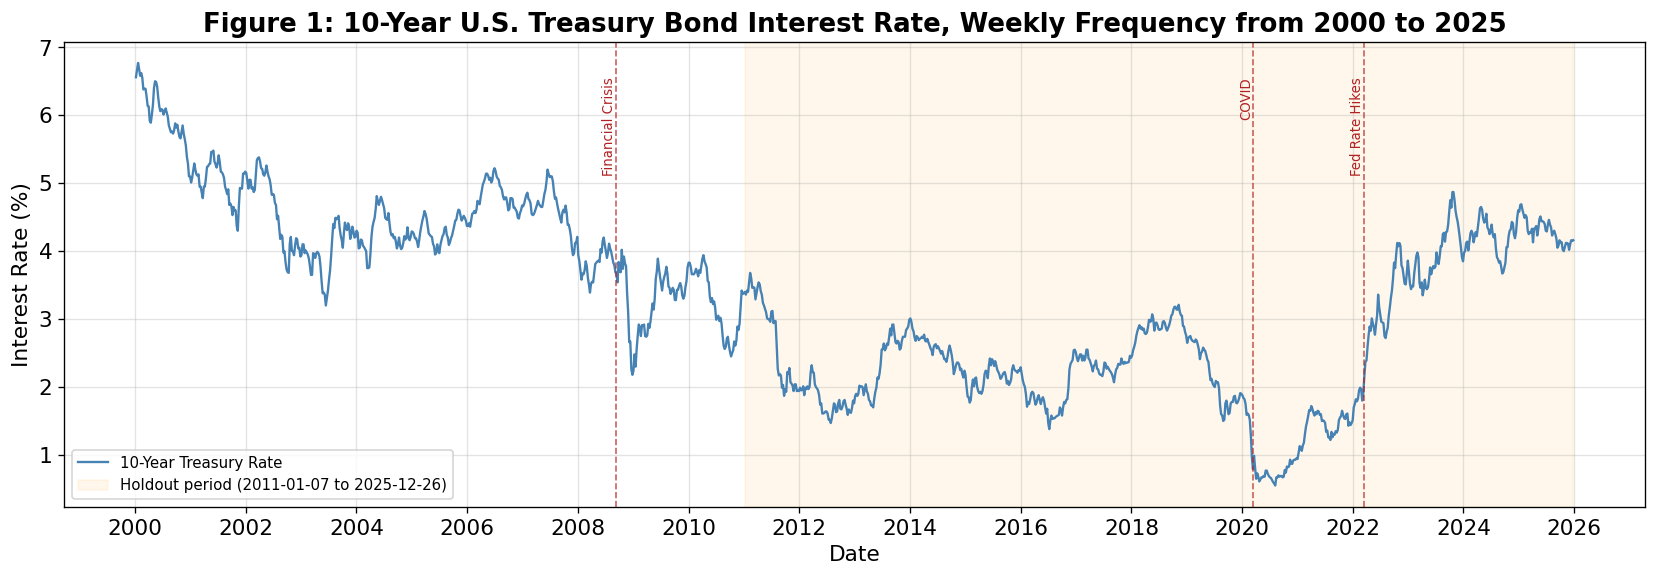

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_ir.index, df_ir['rate'], color='steelblue', lw=1.4, label='10-Year Treasury Rate')

# Shade the holdout period.
ax.axvspan(pd.Timestamp(HOLD_START), pd.Timestamp(HOLD_END),
           alpha=0.08, color='orange', label=f'Holdout period ({HOLD_START} to {HOLD_END})')

# Annotate economic events that strongly impacted the federal funds rate.
events = [
    ('2008-09-12', 'Financial Crisis'),
    ('2020-03-13', 'COVID'),
    ('2022-03-18', 'Fed Rate Hikes'),
]
for date_str, label in events:
    ts = pd.Timestamp(date_str)
    ax.axvline(ts, color='firebrick', lw=1.0, ls='--', alpha=0.7)
    ax.text(ts, df_ir['rate'].max() * 0.97, label,
            fontsize=8, color='firebrick', ha='right', va='top', rotation=90)

ax.set_title('Figure 1: 10-Year U.S. Treasury Bond Interest Rate, Weekly Frequency from 2000 to 2025',
             fontweight='bold')
ax.set_ylabel('Interest Rate (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Discussion on Figure 1

&nbsp;&nbsp;&nbsp;&nbsp;The federal funds rate and the 10-year U.S. Treasury Bond interest rate typically move in the same direction, ie have a positive relationship. When the Fed raises the funds rate, markets update their expectations for future short term rates and the 10-year interest rate rises with it. However, during periods of economic crisis this relationship may not hold as investors seek stability in 
U.S. Treasury Bonds, driving bond prices up and interest rates down regardless of Fed policy.

&nbsp;&nbsp;&nbsp;&nbsp; From 2000 to 2008 the interest rate had an overall downward trend before the Financial Crisis triggered a sharp drop caused by investors seeking reliable returns in bonds. As the economy slowly recovered, the Fed held the funds rate near zero for years, keeping the 10-year interest rate low, encouraging investment in financial assets outside of the bonds market. In 2015, the Fed began cautiously raising the funds rate. The 10-year interest rate increased, demonstrating the typical positive relationship between the funds rate and bond interest rates.

&nbsp;&nbsp;&nbsp;&nbsp;COVID in 2020 caused a sharp interest rate decrease as the Fed cut rates to near zero again. As seen in previous assignments, the economy recovered from the COVID crisis far faster than from the 2008 Financial Crisis, which led the Fed to quickly raise interest rates throughout 2022. The rapid increase in 10-year interest rates from 1% in 2020 to nearly 4% in 2022 will be a challenge for all five forecasting models, as there is no such rapid increase in the training period.


In [7]:
ir_summary_stats_dict = summary_statistics(
    df_ir,
    'rate',
    'date'
)
display(ir_summary_stats_dict)

{'df_summary_stats':   statistic   value
 0      mean  3.3220
 1    median  3.4250
 2       var  1.6747
 3   std_dev  1.2941
 4  skewness  0.0484
 5  kurtosis -0.7331,
 'min_date': Timestamp('2000-01-07 00:00:00'),
 'max_date': Timestamp('2025-12-26 00:00:00')}

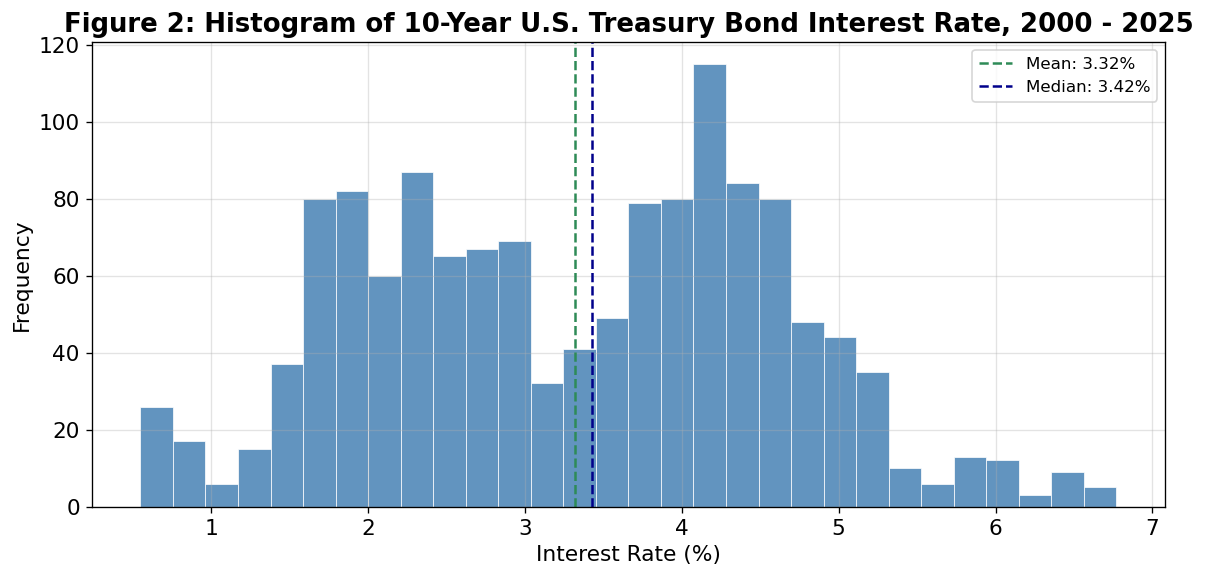

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df_ir['rate'],
    bins=30,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

ax.axvline(
    df_ir['rate'].mean(),
    color='seagreen',
    lw=1.5,
    ls='--',
    label=f"Mean: {df_ir['rate'].mean():.2f}%"
)
ax.axvline(
    df_ir['rate'].median(),
    color='darkblue',
    lw=1.5,
    ls='--',
    label=f"Median: {df_ir['rate'].median():.2f}%"
)

ax.set_title('Figure 2: Histogram of 10-Year U.S. Treasury Bond Interest Rate, 2000 - 2025',
             fontweight='bold')
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#### Discussion on Figure 2 and Summary Statistics

&nbsp;&nbsp;&nbsp;&nbsp;Let's consider the summary statistics of 10-year interest rates across the entire sample timeframe and how they relate to Figure 1. A nearly zero skew of 0.0484 and the bimodal shape of the histogram suggests 2 intervals for interest rates (0%, 3%] and 
(3%, 7%). In Figure 1, interest rate from 1% to 3% is typical in the years from 2008 to 2022, while interest rate from 4% to 6% is typical outside of those years.

&nbsp;&nbsp;&nbsp;&nbsp;Standard deviation in economic terms here can be thought of as volatility in the 10-year U.S. Treasury Bond interest rate. A standard deviation of 1.29, with all observed interest rates in the sample between 0% and 7%, represents notable volatility in the sample.

&nbsp;&nbsp;&nbsp;&nbsp;The mean 3.32% less than the median 3.42% suggests that the mean is pulled down by periods of economic crisis. The negative excess kurtosis of -0.7331 indicates flatter tails in the distribution, ie not many extreme observations.


# Question 1.3 - Create forecasts, h=1.

#### Discussion on models and code implementation.

&nbsp;&nbsp;&nbsp;&nbsp;The five models evaluated here are all naive forecast methods as defined in Lecture 7 slides 3–11. At each forecast origin $t$, we produce a 1 step ahead forecast $\hat{y}_{t+1|t}$ of the interest rate $y_{t+1}$. For Models 1A, 1B, and 1C, the forecast is simply a rolling average of the last $S$ observations using a fixed window. For Model 2, the drift $\hat{\alpha}_t$ is re-estimated at each step using an expanding window over all data up to $t$, ie the recursive expanding window method. Since $S = 1$ in Model 1A, Model 3 is the same as Model 1A.

**Model 1A, 1B, 1C - Simple Mean Models, no recursive expanding window:**
$$\hat{y}_{t+1|t} = \bar{y}_{t,S} = \frac{1}{S}\sum_{i=t-S+1}^{t} y_i$$
The forecast is the mean of the $S$ most recent observations. Three variants are evaluated:
- **Model 1A ($S=1$):** $\hat{y}_{t+1|t} = y_t$<br>Forecast is simply the most recent observation.

- **Model 1B ($S=4$):** $\hat{y}_{t+1|t} = \frac{1}{4}\sum_{i=t-3}^{t} y_i$<br>Mean of the last 4 weeks, approximately 1 month.

- **Model 1C ($S=52$):** $\hat{y}_{t+1|t} = \frac{1}{52}\sum_{i=t-51}^{t} y_i$<br>Mean of the last 52 weeks, approximately 1 year.

In pandas, a rolling mean of window $S$ shifted forward by 1 period correctly aligns the forecast $\hat{y}_{t+1|t}$ with the observed value $y_{t+1}$.

**Model 2 - Random Walk with Drift (RWD), uses recursive expanding window:**
$$y_t = \alpha + y_{t-1} + \varepsilon_t \implies \hat{y}_{t+1|t} = y_t + \hat{\alpha}_t$$
The OLS estimate of the drift $\hat{\alpha}_t$ at forecast origin $t$ is the expanding mean of all first differences up to time $t$, as stated in Lecture 7, slides 10–11:
$$\hat{\alpha}_t = \frac{1}{t-1}\sum_{i=2}^{t}\Delta y_i = \frac{y_t - y_1}{t-1}$$
This is computed recursively using `pandas.Series.diff().expanding().mean()`.

**Model 3 - Random Walk (RW, no drift), no recursive expanding window:**
$$y_t = y_{t-1} + \varepsilon_t \implies \hat{y}_{t+1|t} = y_t$$
The forecast is simply the last observed value, thus satisfying the definition of a random walk forecast as defined in Lecture 7 slide 4.

**Note on Models 1A and 3:** With $S=1$, Model 1A reduces to $\hat{y}_{t+1|t} = y_t$, which is identical to Model 3. Both models will produce the same forecasts, forecast errors, and MSFE.

#### Run the forecasting code.

In [9]:
### NOTE:
# Earlier in the notebook, we checked that the interest data is in fact
# at a weekly frequency, and set the date column as the index of df_ir.
# Thus we can be sure that .shift(1) is performing a weekly shift and do not
# need to specify the frequency in the shift.
####

# Make a copy of the interest column, calling it y since this is
# what we are forecasting.
y = df_ir['rate'].copy()

#### Model 1A, 1B, 1C ####
# Rolling mean of S observations, shifted 1 period ahead, t+1.
# At holdout position t+1, rolling(S).mean().shift(1) gives the mean of [y_{t-S+1}, ..., y_t],
# using only data available at forecast origin t.
# S=1 reduces to y_t.
fc_1a = y.rolling(1).mean().shift(1)
# S=4 gives the mean over the last 4 weeks.
fc_1b = y.rolling(4).mean().shift(1)
# S=52 gives the mean over the last 52 weeks
fc_1c = y.rolling(52).mean().shift(1)
####


#### Model 2: Random Walk with Drift. ####
# Expanding mean of first differences gives alpha_hat at each t.
# shift(1) ensures we use alpha estimated only up to t, not t+1.
alpha_hat = y.diff().expanding().mean()
fc_2 = y.shift(1) + alpha_hat.shift(1)
####


#### Model 3: Random Walk. ####
fc_3 = y.shift(1)
####


# Create the forecast DataFrame, restricting to the holdout timeframe.
# Assign holdout_idx to the indexes associated with the holdout timeframe.
holdout_idx = df_ir.loc[HOLD_START:HOLD_END].index

df_fc = pd.DataFrame({
    'actual': y.loc[holdout_idx],
    'fc_1a': fc_1a.loc[holdout_idx],
    'fc_1b': fc_1b.loc[holdout_idx],
    'fc_1c': fc_1c.loc[holdout_idx],
    'fc_2': fc_2.loc[holdout_idx],
    'fc_3': fc_3.loc[holdout_idx]
    },
    index=holdout_idx
)

# Forecast errors are calculated as actual minus forecast as in previous
# assignments, and as is specified in Lecture 5 slide 12.
for fc_col, e_col in zip(FC_COLS, ERR_COLS):
    df_fc[e_col] = df_fc['actual'] - df_fc[fc_col]


# Dates should've stayed in ASC order.
assert df_fc.index.is_monotonic_increasing, "Dates are expected to be sorted ASC."

# Ensure that none of the holdout data is in the training data.
# The first RW forecast must equal the last training observation.
# This confirms no look ahead at the boundary of training and holdout.
assert df_fc.loc[HOLD_START, 'fc_3'] == df_ir.loc[TRAIN_END, 'rate'],\
    "First RW forecast should equal the last training observation."

# More holdout checks.
assert df_fc.index[0].strftime("%Y-%m-%d") == HOLD_START
assert df_fc.index[-1].strftime("%Y-%m-%d") == HOLD_END

# Use P calculated in Question 1.1 to validate the number of forecasts created.
assert df_fc.shape[0] == P, f"Expected {P} holdout rows, got {df_fc.shape[0]}"

# There shouldn't be any nulls in the forecast.
assert not df_fc.isnull().any().any(), "Unexpected NaNs in forecast DataFrame."

# Model 1A and Model 3 must be identical in both forecast and forecast errors.
assert df_fc['fc_1a'].equals(df_fc['fc_3']), "Model 1A and Model 3 should be identical."
assert df_fc['e_1a'].equals(df_fc['e_3']), "Errors for Model 1A and Model 3 should be identical."

print(f"Holdout period: {df_fc.index[0].strftime('%Y-%m-%d')} to {df_fc.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of forecasts P: {df_fc.shape[0]}")
print("\nFirst 5 rows of forecasts and errors:")
display(df_fc.head())
print("\nLast 5 rows of forecasts and errors:")
display(df_fc.tail())

Holdout period: 2011-01-07 to 2025-12-26
Number of forecasts P: 782

First 5 rows of forecasts and errors:


,actual,fc_1a,fc_1b,fc_1c,fc_2,fc_3,e_1a,e_1b,e_1c,e_2,e_3
date,,,,,,,,,,,
2011-01-07,3.40,3.38,3.3375,3.210769,3.374450,3.38,0.02,0.0625,0.189231,0.025550,0.02
2011-01-14,3.36,3.40,3.3925,3.202500,3.394495,3.40,-0.04,-0.0325,0.157500,-0.034495,-0.04
2011-01-21,3.42,3.36,3.3775,3.194615,3.354435,3.36,0.06,0.0425,0.225385,0.065565,0.06
2011-01-28,3.40,3.42,3.3900,3.190000,3.414549,3.42,-0.02,0.0100,0.210000,-0.014549,-0.02
2011-02-04,3.54,3.40,3.3950,3.185000,3.394523,3.40,0.14,0.1450,0.355000,0.145477,0.14



Last 5 rows of forecasts and errors:


,actual,fc_1a,fc_1b,fc_1c,fc_2,fc_3,e_1a,e_1b,e_1c,e_2,e_3
date,,,,,,,,,,,
2025-11-28,4.02,4.11,4.1025,4.320962,4.108185,4.11,-0.09,-0.0825,-0.300962,-0.088185,-0.09
2025-12-05,4.10,4.02,4.0925,4.316538,4.018120,4.02,0.08,0.0075,-0.216538,0.081880,0.08
2025-12-12,4.16,4.10,4.0875,4.314808,4.098180,4.10,0.06,0.0725,-0.154808,0.061820,0.06
2025-12-19,4.15,4.16,4.0975,4.312500,4.158226,4.16,-0.01,0.0525,-0.162500,-0.008226,-0.01
2025-12-26,4.16,4.15,4.1075,4.306154,4.148220,4.15,0.01,0.0525,-0.146154,0.011780,0.01


#### ARIMA Validation of Model 2 (RWD) and Model 3 (RW)

&nbsp;&nbsp;&nbsp;&nbsp;To validate the pandas vectorized code in Model 2 RWD and Model 3 RW, use statsmodels ARIMA as done at the end of the assignment 3 solutions notebook.

In [10]:
# Per Assignment 3 solutions:
# RW = ARIMA(0,1,0) no trend
# RWD = ARIMA(0,1,0) with trend.
# Checking all of the forecasts is time consuming and unnecessary.
NUM_ARIMA_CHECKS = 10

y_vals = df_ir['rate'].copy().values
# Set a random state for reproducible results.
sampled_idx = holdout_idx.to_series().sample(n=NUM_ARIMA_CHECKS, random_state=1).sort_index()
holdout_positions = [df_ir.index.get_loc(idx) for idx in sampled_idx]

rows = []
for i, pos in enumerate(holdout_positions):
    history = y_vals[:pos]

    # ARIMA RWD.
    fc_rwd_arima = ARIMA(history, order=(0, 1, 0), trend='t').fit().forecast(steps=1)[0]
    # ARIMA RW.
    fc_rw_arima = ARIMA(history, order=(0, 1, 0), trend='n').fit().forecast(steps=1)[0]

    rwd_vect = df_fc.loc[sampled_idx.iloc[i], 'fc_2']
    rw_vect = df_fc.loc[sampled_idx.iloc[i], 'fc_3']

    rows.append({
        'date': sampled_idx.iloc[i].strftime('%Y-%m-%d'),
        'rw_vect': round(rw_vect, 4),
        'rw_arima': round(fc_rw_arima, 4),
        # rw_match is dtype bool.
        'rw_match': abs(rw_vect - fc_rw_arima) < 1e-6,
        'rwd_vect': round(rwd_vect, 4),
        'rwd_arima': round(fc_rwd_arima, 4),
        # rwd_match is dtype bool.
        'rwd_match': abs(rwd_vect - fc_rwd_arima) < 1e-4,
    })

df_arima_check = pd.DataFrame(rows).set_index('date')
display(df_arima_check)
assert df_arima_check['rw_match'].all() and df_arima_check['rwd_match'].all(),\
    "ARIMA validation failed. Sampled vectorized forecasts do not match ARIMA."

,rw_vect,rw_arima,rw_match,rwd_vect,rwd_arima,rwd_match
date,,,,,,
2013-02-22,2.01,2.01,True,2.0033,2.0033,True
2014-11-21,2.36,2.36,True,2.3546,2.3546,True
2016-02-05,2.00,2.00,True,1.9946,1.9946,True
2016-10-14,1.70,1.70,True,1.6944,1.6944,True
2017-07-07,2.23,2.23,True,2.2253,2.2252,True
2021-06-25,1.51,1.51,True,1.5055,1.5055,True
2021-09-17,1.35,1.35,True,1.3454,1.3454,True
2022-12-30,3.67,3.67,True,3.6676,3.6676,True
2023-06-02,3.76,3.76,True,3.7577,3.7577,True


# Question 1.4 - Plot forecasts vs original data.

#### Note: As confirmed in Question 1.3, Model 1A and Model 3 are equivalent. In Figure 3, to avoid overplotting only Model 1A will be plotted, and a note of this will be made in the legend. Figure 4 plots actual vs every model individually for a closer look.

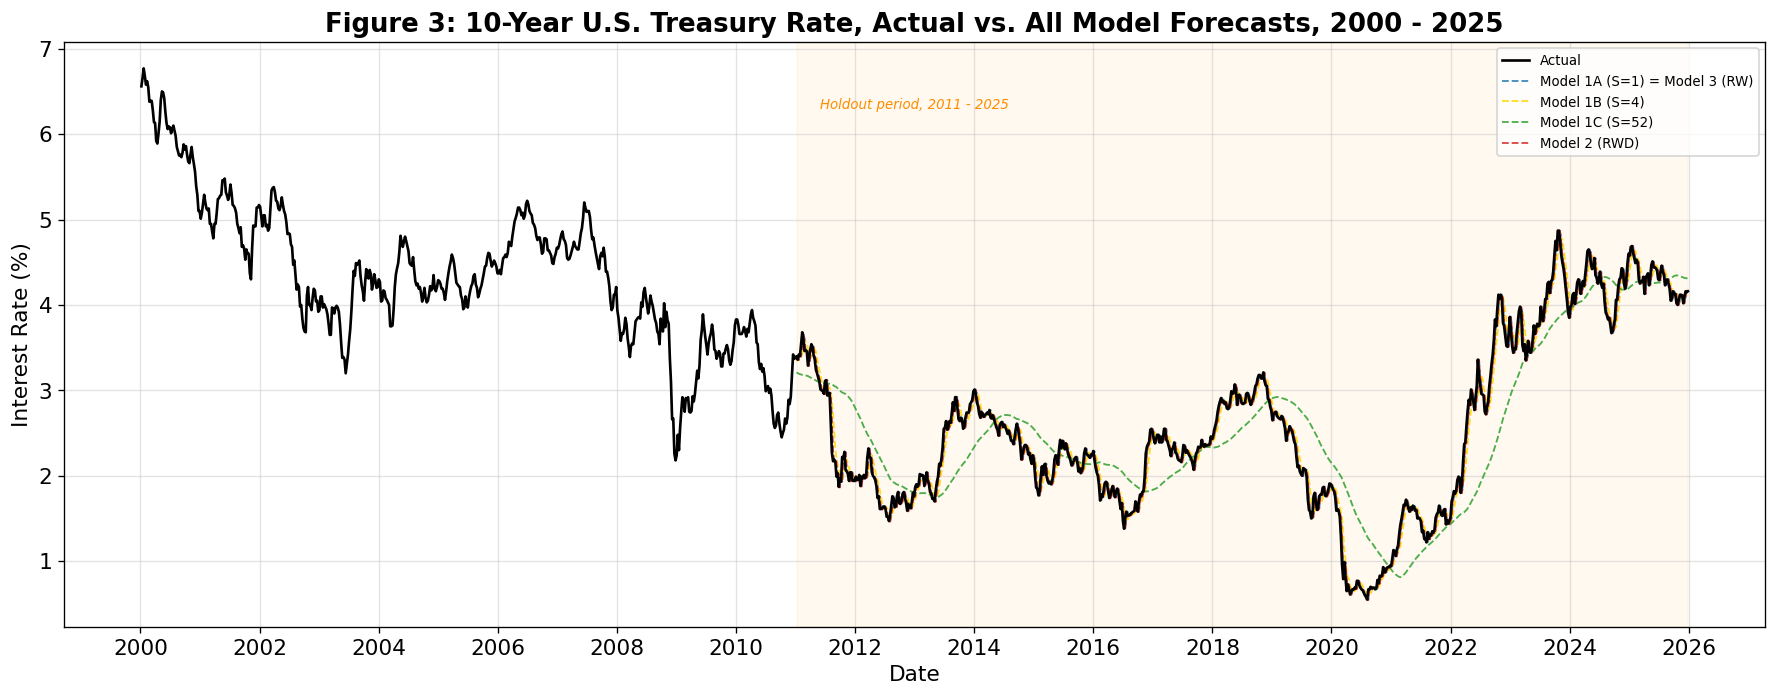

In [11]:
fig, ax = plt.subplots(figsize=(15, 6))

# Plot full actual data, entire 2000-2025 sample.
ax.plot(
    df_ir.index,
    df_ir['rate'],
    color='black',
    lw=1.6,
    label='Actual',
    zorder=5
)

# Shade the holdout period.
ax.axvspan(
    pd.Timestamp(HOLD_START),
    pd.Timestamp(HOLD_END),
    alpha=0.06,
    color='orange'
)

# Plot each model's forecast over the holdout period, except Model 3. In
# Question 1.3, we confirmed that both the forecast and the forecast error
# of Model 1A and Model 3 are identical. Thus to avoid messy plot,
# don't plot Model 3. In the legend, will indicate that
# Model 1A = Model 3.
for fc_col, label, color in zip(FC_COLS, MODEL_LABELS, MODEL_COLORS):
    if fc_col == 'fc_1a':
        label = 'Model 1A (S=1) = Model 3 (RW)'
    else:
        pass

    if fc_col == 'fc_3':
        continue
    else:
        ax.plot(
            df_fc.index,
            df_fc[fc_col],
            color=color,
            lw=1.1,
            ls='--',
            label=label,
            alpha=0.85
        )

ax.set_title(
    'Figure 3: 10-Year U.S. Treasury Rate, Actual vs. All Model Forecasts, 2000 - 2025',
    fontweight='bold'
)
ax.set_ylabel('Interest Rate (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=8, loc='upper right')
ax.text(
    pd.Timestamp('2011-06-01'),
    df_ir['rate'].max() * 0.93,
    'Holdout period, 2011 - 2025',
    fontsize=8,
    color='darkorange',
    style='italic'
)
plt.tight_layout()
plt.show()

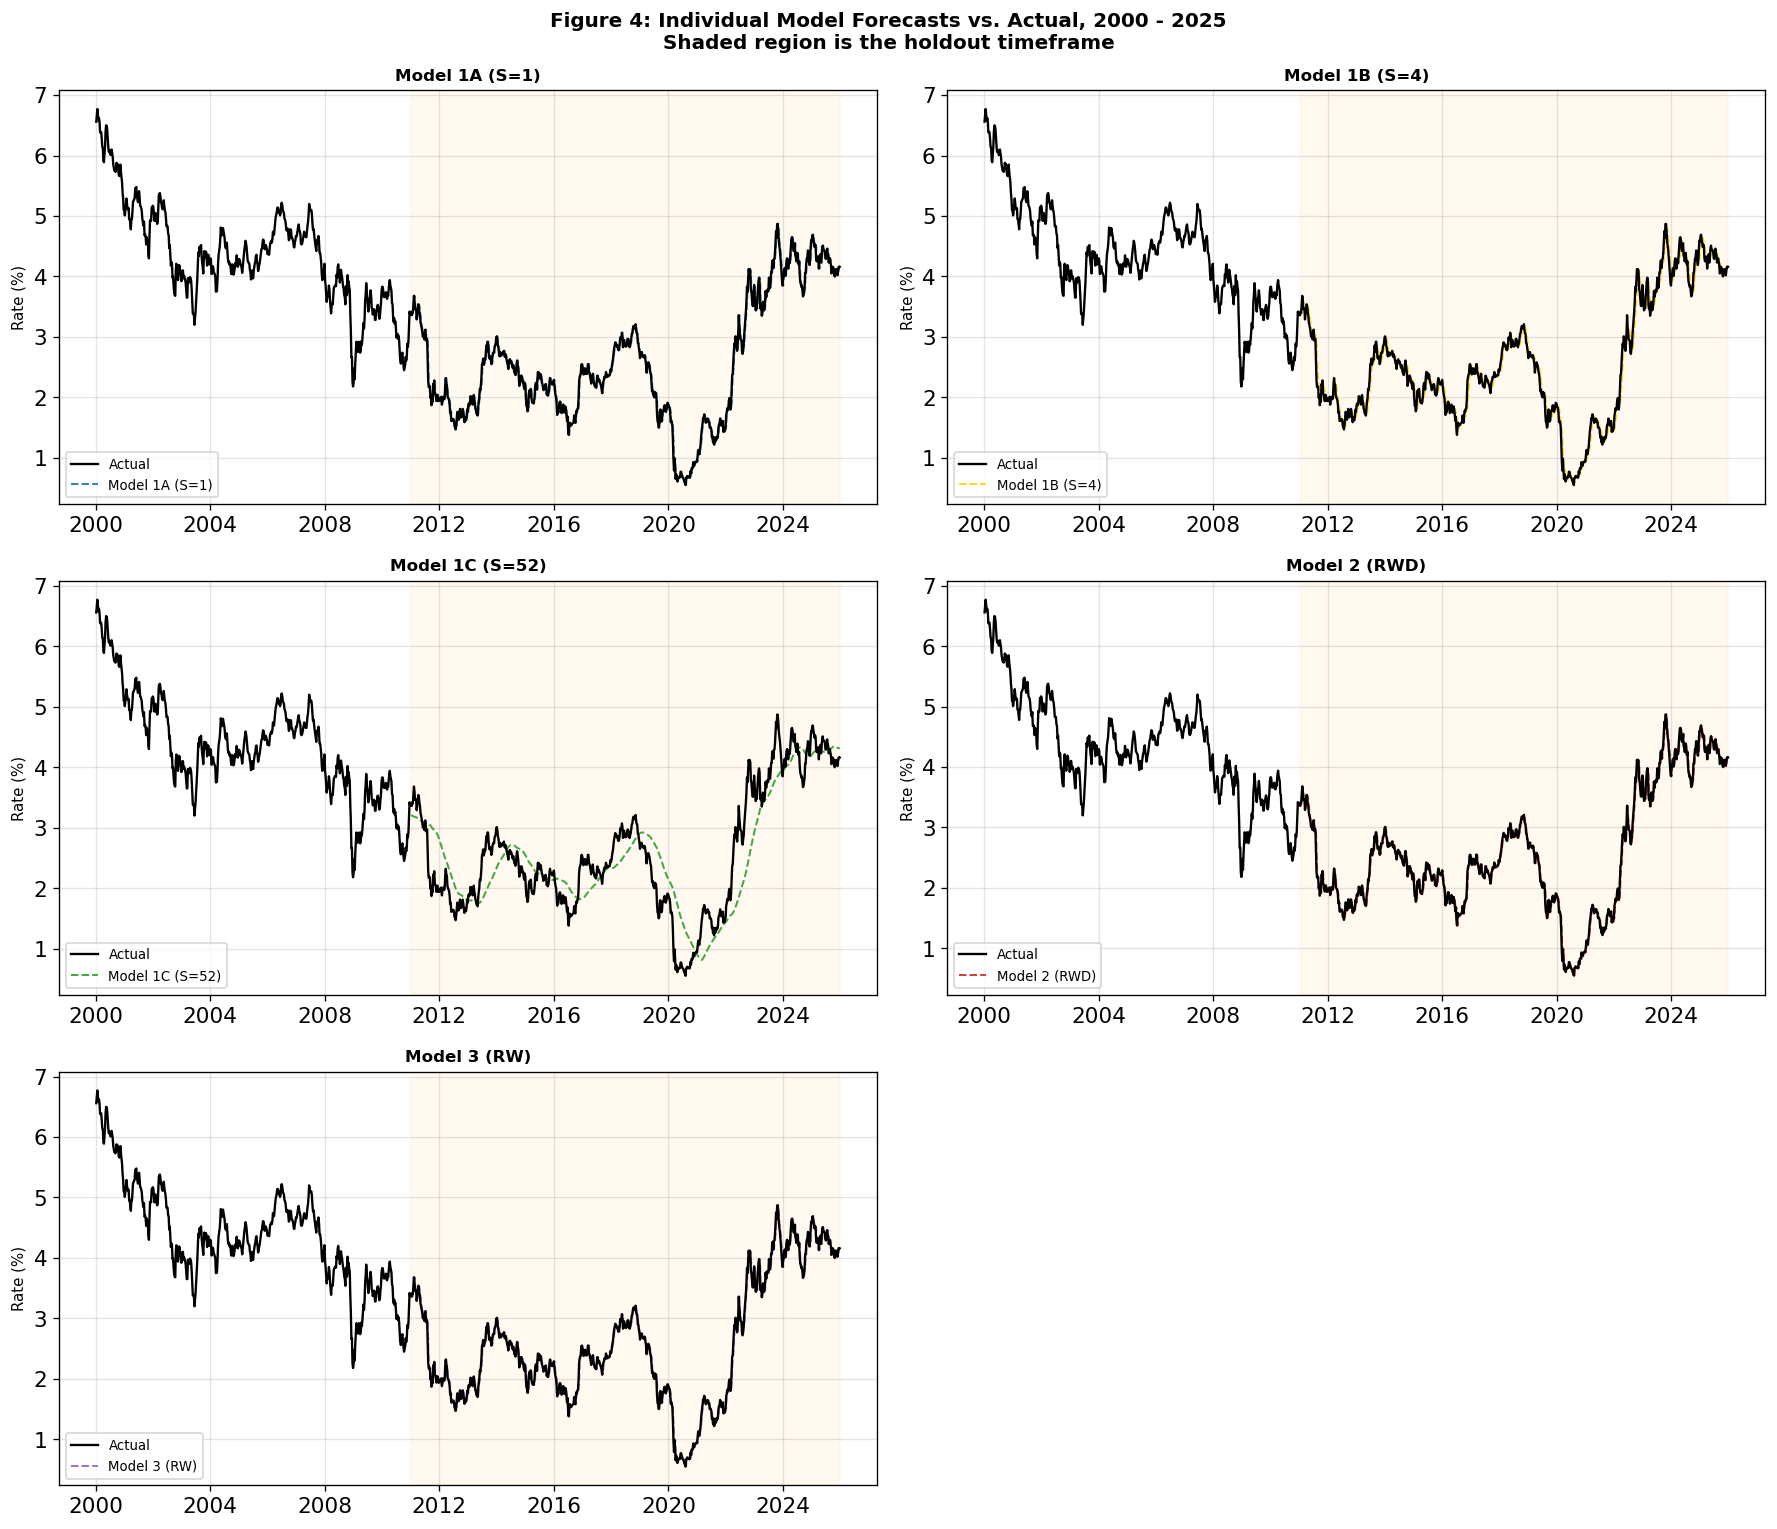

In [12]:
# Individual model plots, one subplot per model. Gives clearer comparison.
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.flatten()

for i, (fc_col, label, color) in enumerate(zip(FC_COLS, MODEL_LABELS, MODEL_COLORS)):
    ax = axes[i]
    # Full actual series in background.
    ax.plot(
        df_ir.index,
        df_ir['rate'],
        color='black',
        lw=1.4,
        label='Actual',
        zorder=5
    )
    # Forecast over holdout only.
    ax.plot(
        df_fc.index,
        df_fc[fc_col],
        color=color,
        lw=1.2,
        ls='--',
        label=label,
        alpha=0.9
    )
    # Shade the holdout timeframe.
    ax.axvspan(
        pd.Timestamp(HOLD_START),
        pd.Timestamp(HOLD_END),
        alpha=0.06,
        color='orange'
    )
    ax.set_ylabel('Rate (%)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.legend(fontsize=8)
    # Just plot both Model 1A and Model 3.
    # if fc_col == 'fc_1a':
    #     label='Model 1A (S=1) = Model 3 (RW)'
    # else:
    #     pass
    ax.set_title(
        label,
        fontweight='bold',
        fontsize=10
    )

# Turn off the unused 6th subplot.
axes[5].set_visible(False)

fig.suptitle(
    'Figure 4: Individual Model Forecasts vs. Actual, 2000 - 2025\nShaded region is the holdout timeframe',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Discussion of Figures 3 and 4.

&nbsp;&nbsp;&nbsp;&nbsp;Figures 3 and 4 display the 10-year Treasury rate along with the h=1 week-ahead forecasts from all five models over the holdout period, 2011 – 2025.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 1A and Model 3 (Random Walk)** are visually nearly identical, which is expected per the note in Question 1.3 discussion. Models 1A and Model 3 track the actual series closely with a one week lag, ie forecasted interest rate for a given week is simply the previous week's interest rate. These models adapt quickly to economic shocks or brief spikes in a h=1 week forecast horizon - any change in the interest rate this week will be included in the forecast next week.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 1B ($S=4$)** applies a 4 week rolling mean, which tracks the actual series somewhat closely. The 4 weeks lag results in the model taking longer to adapt to economic shocks or brief spikes, compared against Model 1A and Model 3.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 1C ($S=52$)** applies a 52-week rolling mean. This produces a noticeably smoother, slower moving forecast that is visually more distant from the actual series, demonstrating the slowness with which this model adapts to changes in interest rates.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 2 (RWD)** adds a recursively estimated drift term to the random walk. Given the long run downward trend in rates over most of the sample, the drift will be estimated as slightly negative during early holdout years, biasing forecasts downward. During the sharp increase of interest rate in 2022, the negative drift hurts performance as it struggles to adjust to the positive trend.


# Question 1.5 - MSFE and MAFE

#### Discussion on Loss Functions MSFE and MAFE.

&nbsp;&nbsp;&nbsp;&nbsp;Loss functions allow us to measure forecast accuracy and thus select the best model. The two loss functions we use in this question are MSFE and MAFE, which are both derived from a more general class of loss functions as discussed towards the end of Lecture 6 and throughout Lecture 7.

**MSFE** is derived from quadratic loss $L(e) \propto e^2$, which penalises large errors disproportionately:
$$\text{MSFE} = \frac{1}{P}\sum_{t=2011:1}^{2025:52}\left(y_{t+1} - \hat{y}_{t+1|t}\right)^2$$

**MAFE** is derived from absolute loss $L(e) \propto |e|$, which penalises all errors in proportion to their magnitude:
$$\text{MAFE} = \frac{1}{P}\sum_{t=2011:1}^{2025:52}\left|y_{t+1} - \hat{y}_{t+1|t}\right|$$

where $P = 782$, $\hat{y}_{t+1|t}$ is the h=1 week-ahead forecast made at time $t$, and $y_{t+1}$ is the observed interest rate.

In [21]:
# Compute MSFE and MAFE for each model over the holdout period.
# MSFE per Lecture 7, slide 17; mean of squared errors; quadratic loss.
# MAFE per Lecture 7, slide 18; mean of absolute errors; absolute loss.
msfe_vals = [(df_fc[e_col] ** 2).mean() for e_col in ERR_COLS]
mafe_vals = [df_fc[e_col].abs().mean() for e_col in ERR_COLS]

df_loss = pd.DataFrame({
    'Model': MODEL_LABELS,
    'MSFE': msfe_vals,
    'MAFE': mafe_vals,
}).set_index('Model')
# Since the question only asks for MSFE, sort ASC by MSFE, best to worst.
df_loss = df_loss.sort_values(by=['MSFE'])

print('MSFE and MAFE - All 5 Models\nHoldout Period 2011-01-07 to 2025-12-26\nP=782 forecasts')
display(
    df_loss.style\
    .format({'MSFE': '{:.6f}', 'MAFE': '{:.6f}'})\
    .highlight_min(subset=['MSFE'], color='darkgreen')\
    .highlight_max(subset=['MSFE'], color='darkred')\
    .highlight_min(subset=['MAFE'], color='darkgreen')\
    .highlight_max(subset=['MAFE'], color='darkred')\
    .set_caption('MSFE and MAFE')
)
print('Green is best, ie smallest errors. Red is worst, ie highest errors.')

MSFE and MAFE - All 5 Models
Holdout Period 2011-01-07 to 2025-12-26
P=782 forecasts


,MSFE,MAFE
Model,,
Model 1A (S=1),0.008399,0.070230
Model 3 (RW),0.008399,0.070230
Model 2 (RWD),0.008426,0.070327
Model 1B (S=4),0.020439,0.109687
Model 1C (S=52),0.248329,0.390015


Green is best, ie smallest errors. Red is worst, ie highest errors.


#### Discussion on results of MSFE and MAFE.

&nbsp;&nbsp;&nbsp;&nbsp;Both MSFE and MAFE agree on the model rankings. **Model 1A**, which is equivalent to **Model 3**, and **Model 2 (RWD)** are essentially tied for first, as the drift turns out to change very little compared to the RW without drift, despite the downward trend in the drift. **Model 1B** ranks third, as the 4 week averaging lags behind the weekly numbers. **Model 1C** is the worst performer by far, as the 52 week mean cannot respond quickly to interest rate changes, particularly the interest rate steep increase in 2022 of the holdout timeframe. The agreement between both metrics confirms the result is robust to the choice of loss function.

# Question 1.6 - Preferred Model

&nbsp;&nbsp;&nbsp;&nbsp;The Random Walk, Model 1A and Model 3, is the preferred forecasting model for the 10-year U.S. Treasury interest rate at the h=1 week ahead forecast horizon, as evaluated by MSFE and MAFE over the 2011–2025 holdout period. The reasoning for this has already been discussed in Questions 1.4 and 1.5, so let's turn to the economic interpretation of our findings.

**Economic interpretation of Random Walk as the preferred model**<br>
&nbsp;&nbsp;&nbsp;&nbsp;As discussed in class, the 10-year U.S. Treasury rate, and many other economic time series, is known to follow a random walk over short horizons. This is consistent with the Efficient Market Hypothesis - if the rate reflected all available information, then the best prediction for next week's rate is simply this week's rate.
